In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# SINGLE QUOTE CUSTOMERS FILTERING
print("\n🎯 FILTERING TO SINGLE QUOTE CUSTOMERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Count quotes per customer
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='quote_count')

# Get customers with exactly 1 quote
single_quote_ids = quote_counts[quote_counts['quote_count'] == 1]['numero_compte'].tolist()

# Filter data
df_quotes_single = df_quotes[df_quotes['numero_compte'].isin(single_quote_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Single quote customers: {len(single_quote_ids):,}")
print(f"Quotes: {len(df_quotes_single):,}")

# Save to file
df_quotes_single.to_csv('cleaned_quote_data_single.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_single.csv")


🎯 FILTERING TO SINGLE QUOTE CUSTOMERS
Original customers: 25,716
Single quote customers: 17,858
Quotes: 17,858

✅ Saved to cleaned_quote_data_single.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_single.csv')


📊 Original quote data: 17,858 quotes from 17,858 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 17,858, Quotes: 17,858
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 17,858 customers | 37.0% converters
⏱️  Execution time: 7.0 seconds
⚠️  7.0s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 17,858
  Total customers: 17,858
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 17,858
    Quotes after filter: 17,858
⚡ Processing 17,858 customers with sequence features...
  Processed 5,000/17,858 customers
  Processed 10,000/17,858 customers
  Processed 15,000/17,858 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 17,858

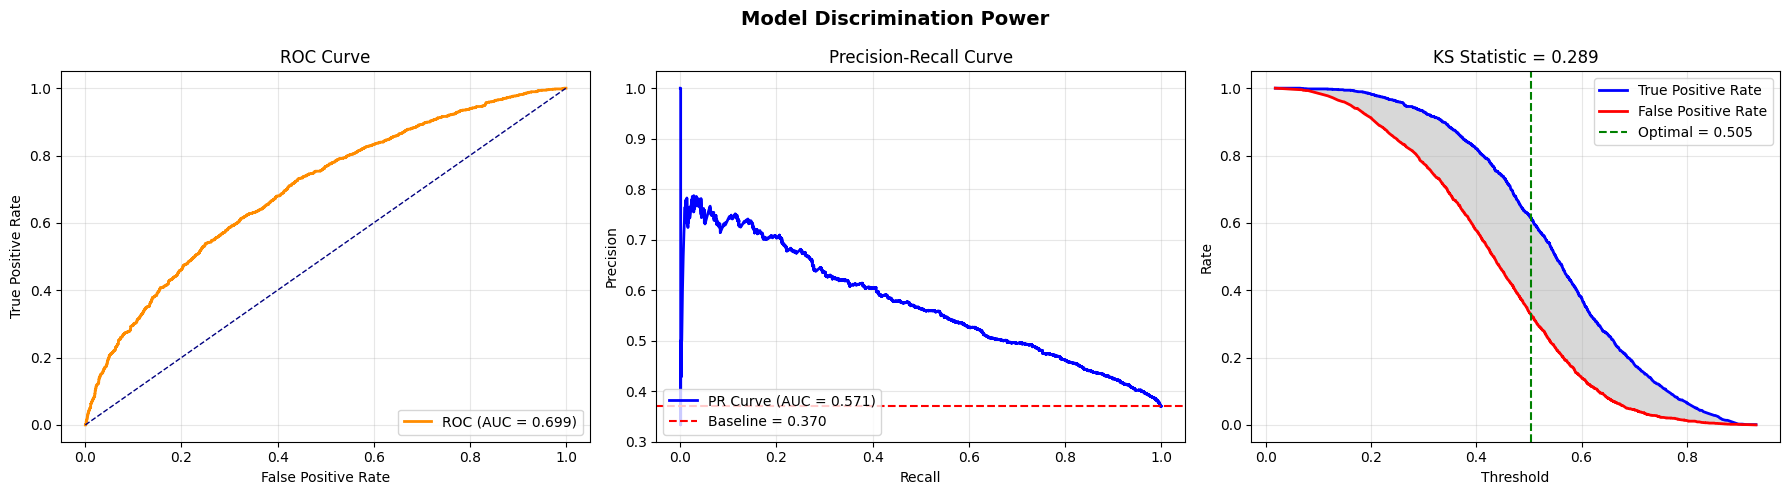

• ROC-AUC: 0.6987
• PR-AUC: 0.5714
• KS Statistic: 0.289 (WEAK discrimination)
• Optimal Threshold: 0.505

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.774
Decile 10 mean prob: 0.174


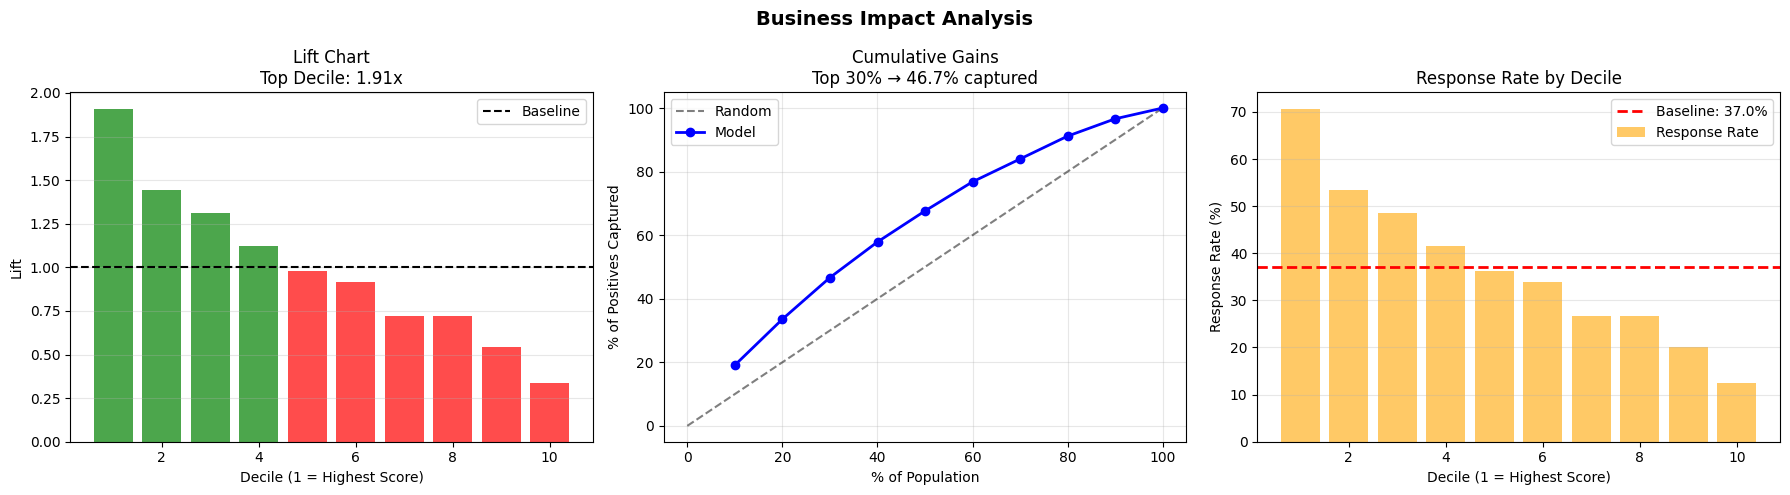

• Top Decile Lift: 0.34x
• Top 30% captures: 46.7% of positives
• Baseline response rate: 37.0%
• Top decile response: 70.7%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


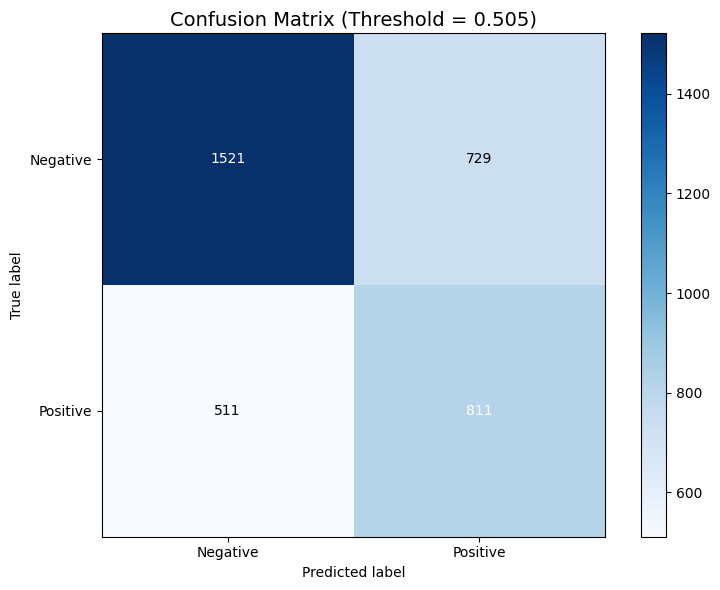

At threshold 0.505:
• Accuracy: 0.653
• Precision: 0.527
• Recall: 0.613
• F1-Score: 0.567
• True Positives: 811
• False Positives: 729
• True Negatives: 1521
• False Negatives: 511

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.289 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.34x better than random
   Coverage: Top 30% → 46.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.6987 (Excellent if >0.8)
   PR-AUC: 0.5714 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.505
   Precision at threshold: 0.527
   Recall at threshold: 0.613

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                                    feature  importance
251                max_price_over_min_price    0.054718
250                             value_score    0.051926
66                            season_winter    0.029733
4                               main_agency    0.027018
203              discount_relative_to_price    0.025624
41               

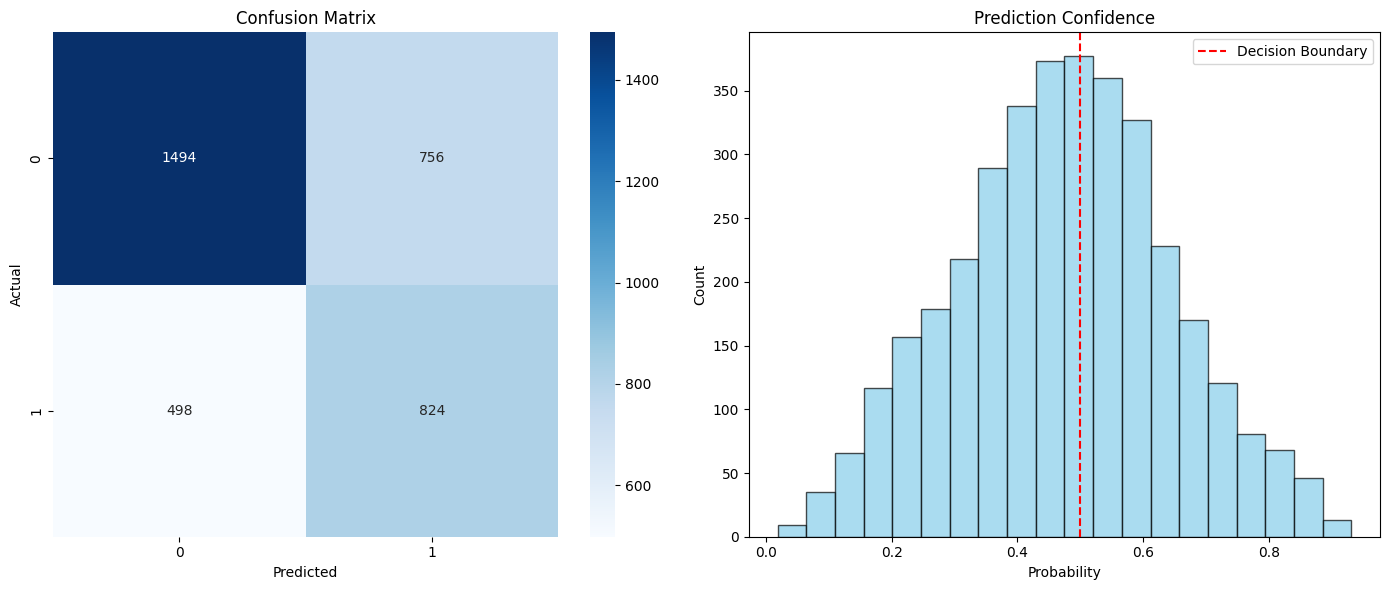

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])